<center>
    <p>115 Theoretical Neuroscience II</p>
    <h1></h1>
    <h1>Lecture 12:</h1>
    <h1>Actor-critic models</h1>
    <p>----</p>
    <p>Prof. Jochen Braun Ph.D.</p>
    <p>Institute of Biology</p>
    <p>Otto-von-Guericke University Magdeburg</p>
    <p>----</p>
    <p>Textbook:</p>
    <p>Peter Dayan & Larry Abbott (2001) Theoretical Neuroscience, MIT Press.</p>
    <p> Sutton & Barto (2018)  Reinforcement Learning, Chapters~3-7, MIT Press. </p>
</center>

The **T-maze** is classic paradigm where sequential action is required to procure delayed reward.  We use maze task to review concepts (policy improvement, evaluation & iteration) and to gain intuitive insight into the operation of actor-critic models.  

**Morris Water maze** is favourite paradigm for hippocampus-dependent learning by rats.  We present and discuss the classic publication by [Foster, Morris, Dayan, 2000](https://www.gatsby.ucl.ac.uk/~dayan/papers/fmd00.pdf).

In **first model** version, training of  'critic' (value map) and 'actor' (local direction preferences) proves slow and inflexible.  In a new environment, the model must unlearn old environment before learning new one.  

In a **second model** version, the 'actor' is complemented with a global direction preference.  This lets model transfer learning between environments and agrees better with animal behaviour.  

We conclude with  **summary** of reinforcement learning.

# **Outline**

**0. Recap**

**1. Sequential action choice**

**2. AC for small T maze**

**3. AC for larger T maze**

**4. Morris water maze**

**5. Extended AC model**

**6. Reinforcement summary**


# **0. Recap**

<br>

In the last lectures, we have considered a  "gridworld" of $N\times N$ states, in which an agent moves randomly until it accidentally finds one of two exits:

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_runs_dumb.png" width="600">



# Policy evaluation

<br>

As our target of learning, we introduced the *value function*, namely, the total reward expected after a state $s$, discounted over all future steps:

$$
V_\pi(s) = \sum_a \pi(a,s) \, \left[ r(a,s) + \gamma V_\pi(s') \right], \qquad s \stackrel{a}{\to} s'
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_values_dumb.png" width="400">

# Policy improvment

<br>

To translate learned information into improved behavior, we further introduced a *policy* $\pi$, namely, a probabilistic mapping from each state $s$ to all available actions $a$:

$$
\pi(a,s)
$$


<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_policy_dumb.png" width="400">


# TD learning

<br>

We concurrently improved both value function and policy, as follows:

<br>

Action and state transition:

$$
a: \qquad s \,\, \rightarrow \,\, s'
$$

<br>

TD prediction error:

$$
\delta_a = r_{s'} + \gamma V_{s'} - V_{s}
$$

<br>

Policy evaluation:

$$
V_s \rightarrow V_s + \alpha \, \delta_a
$$

<br>

Policy improvement:

$$
m_a \rightarrow m_a + \epsilon \, \delta_a
$$


# Actor-critic model

<br>

- Policy $\pi(a,s)$ is the *actor*, as it sets action preferences.

<br>

- Value function $V_\pi(s)$ is the *critic*, as it evaluates total reward expected from policy.


<br>


<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Summary_AC.png" width="400">


# **1. Sequential action choice**

<br>

Seeking to generalize this approach, we consider a classic situation involving sequential actions and delayed rewards, a *maze task*:

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_overview.jpg" width="600">

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_explained.jpg" width="600">

Note that neither choice at A is rewarded immediately.  If the rat goes *left* and *right*, both first and second choice are correct.   However, reinforcement of the first choice is delayed until the second choice is also correct.


# General approach

<br>

As before, our model for reinforcement learning in this task will include the following components:

<br>

- **Actor:** maintains policy and selects actions (given current evaluation).

<br>

- **Policy improvement:**  some mechanism for gradual improvement of policy.

<br>

- **Critic:** maintains estimates of expected total reward (given current policy).

<br>

- **Policy evaluation:** some mechanism for gradual improvement of reward estimates.



For didactic reasons, we consider and compare two approaches:

<br>

**Slow policy iteration:** alternating slowly between policy improvement and reward evaluation (session by session).

<br>

**Fast policy iteration:** alternating quickly between policy improvement and reward evaluation (trial by trial).


# 2. AC for small maze

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_explained.jpg" width="600">

# Actor: stochastic policy

Initially, we set action values $m_a(s)$ to zero, so that choice probabilities become 50\% (random policy):

<br>

**Action values:**

$$
m_{L,R}(A)=\{0, 0\},\qquad m_{L,R}(B)=\{0, 0\},\qquad m_{L,R}(C)=\{0, 0\}\qquad\qquad\qquad
$$

<br>

**Choice probabilities:**

$$
P_L(u) = \frac{1}{1+e^{\beta\, [m_R(u) - m_L(u)]}} = 0.5
\\
\\
P_R(u) = \frac{1}{1+e^{\beta\, [m_L(u) - m_R(u)]}} = 0.5
$$


# Critic: policy evaluation

Given a policy, the total future reward at each position $A$, $B$, or $C$ can be learnt with the temporal difference rule.  If the rat chooses to move from $x$ to $y$, we modify the expected rewards $v{(x)}$ as follows:

$$
v(x) \rightarrow v(x) + \epsilon \, \delta
\qquad\qquad
\delta(x) = r{(x)} + v{(y)} - v{(x)}
$$

where $\delta(x)$ is the *TD prediction error*, $\epsilon$ is a learning rate, and $r{(x)}$ is the immediate reward, if any.
In addition, the prediction error includes the *change of hopes*, i.e. of total expected rewards, between $v(x)$ and $v(y)$.

<br>

In this way, any rewards expected at $y$, but not yet at $x$, are gradually shifted back to $x$, until they are also expected at $x$.

Given a *random policy*, inspection of the maze shows the *average* expected future reward to be

$$
v(B) = \frac{r_L(B)+r_R(B)}{2} = \frac{0+5}{2}=2.5
$$

$$
v(C) = \frac{r_L(C)+r_R(C)}{2}= \frac{0+2}{2}=1
$$

$$
v(A) =  \frac{v(B)+v(C)}{2} = 1.75
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_detail.jpg" width="200">

# Policy evaluation only

<br>

Given random policy, the learned values approach theoretical predictions.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_evaluation.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: theoretical prediction for random policy.

# Direct actor: policy improvement (first slow iteration)


Given a TD prediction error (i.e., expected total reward), the policy (action values) at each position $A$, $B$, or $C$ are improved *directly*.  After turning from $x$ either left or right to $y$, we adjust the action values $m_{L,R}(x)$ as follows:

<br>

**Left turn:**

$$\begin{eqnarray}
m_L(x) \quad \rightarrow & \quad m_L(x) + \epsilon \, \left[1-P_L(x) \right]\,\delta \qquad \\
m_R(x) \quad \rightarrow & \quad m_R(x) - \epsilon \, P_R(x) \, \delta \qquad  
\end{eqnarray}$$

<br>

**Right turn:**

$$\begin{eqnarray}
m_L(x) \quad \rightarrow & \quad m_L(x) - \epsilon \, P_L(x) \, \delta \qquad \\
m_R(x) \quad \rightarrow & \quad m_R(x) + \epsilon \, \left[1-P_R(x) \right] \, \delta \qquad  
\end{eqnarray}$$

$$
\delta = r(y) + v(y) - v(x)
$$

# Policy improvement only (first slow iteration)

Based on *values* $v$ learnt in the earlier evaluation phase, we can now improve policy (action preferences).  Model begins to prefer the right choices (turns):

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_improvement.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: ideal choice probability.

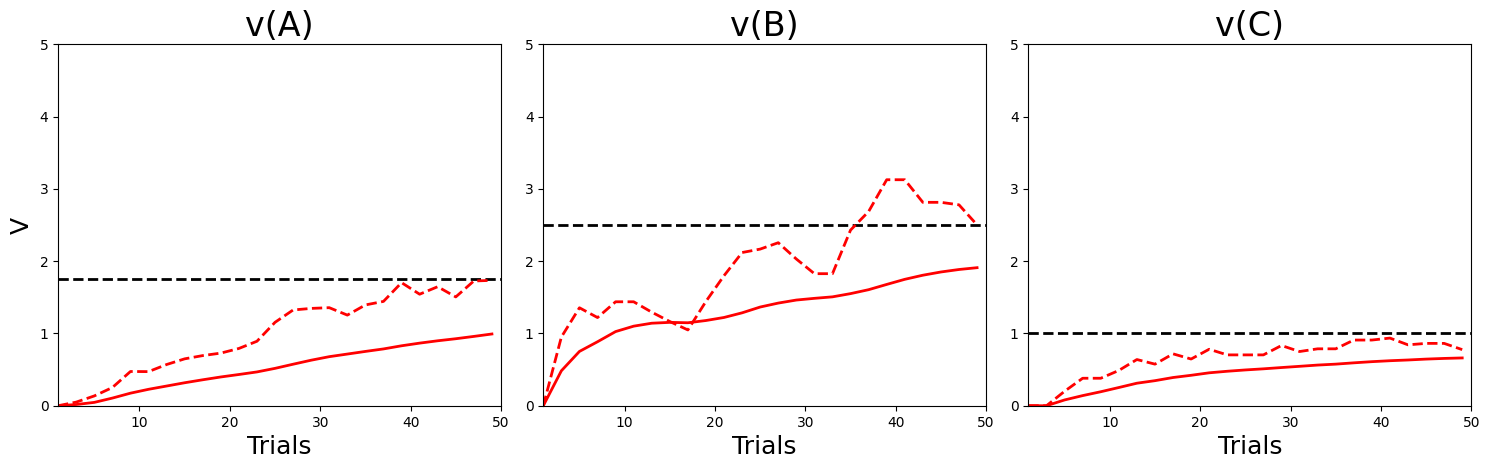

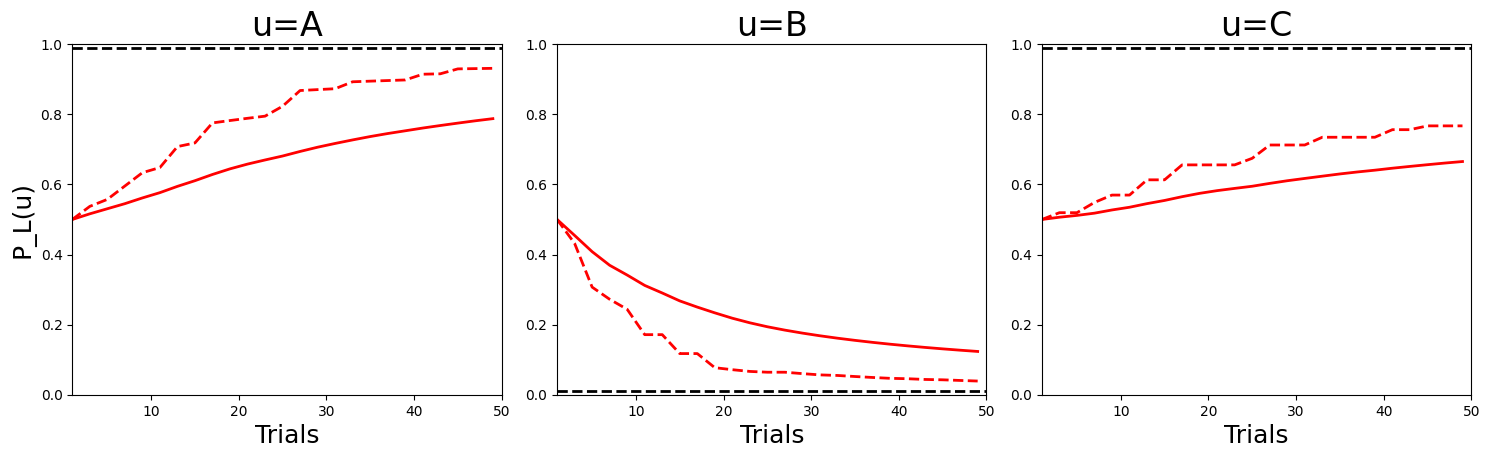

In [ ]:
# @title Policy evaluation, followed by policy improvement {"vertical-output":true,"display-mode":"form"}


import numpy as np
import matplotlib.pyplot as plt

# Global variables
RW = None  # Immediate rewards
VV = None  # Total future rewards
MM = None  # Action values
PP = None  # Choice probabilities
RR = 2     # Right action
LL = 1     # Left action
AA = 1     # State A
BB = 2     # State B
CC = 3     # State C
epsilon = 0.1  # Learning rate for states
alpha = 0.4    # Learning rate for actions

def increment(xx, tt, iflag):
    """
    Updates state values or policy based on position xx (AA, BB, or CC), action tt (RR or LL),
    and flag (1 for evaluation, 2 for improvement).
    """
    global RW, VV, MM, PP, RR, LL, AA, BB, CC, epsilon, alpha

    if xx == AA and tt == LL:
        delta = RW[LL-1, AA-1] + VV[BB-1] - VV[AA-1]
    elif xx == AA and tt == RR:
        delta = RW[RR-1, AA-1] + VV[CC-1] - VV[AA-1]
    elif xx == BB:
        delta = RW[tt-1, BB-1] - VV[BB-1]
    elif xx == CC:
        delta = RW[tt-1, CC-1] - VV[CC-1]

    if iflag == 1:
        VV[xx-1] = VV[xx-1] + epsilon * delta
    elif iflag == 2:
        MM[tt-1, xx-1] = MM[tt-1, xx-1] + epsilon * (1 - PP[tt-1, xx-1]) * delta
        MM[2-tt, xx-1] = MM[2-tt, xx-1] - epsilon * PP[2-tt, xx-1] * delta

# Parameters
beta = 1       # Exploitation/exploration balance
Ntrial = 50    # Number of trials
nsample = 2    # Samples for plotting
Nchoice = 2    # Number of choices (left, right)
Nstate = 3     # Number of states (A, B, C)

# Initialize arrays
MM = np.zeros((Nchoice, Nstate))  # Action values
PP = np.zeros((Nchoice, Nstate))  # Choice probabilities
RW = np.zeros((Nchoice, Nstate))  # Immediate rewards
RW[RR-1, BB-1] = 5                # Reward for right at B
RW[LL-1, CC-1] = 2                # Reward for left at C
VV = np.zeros(Nstate)             # Total future rewards
CC_VV = np.zeros((Ntrial, Nstate))  # Store VV for each trial
CC_PP = np.zeros((Ntrial, Nstate))  # Store PP for each trial

# Compute initial choice probabilities
PP[LL-1, :] = 1 / (1 + np.exp(beta * (MM[RR-1, :] - MM[LL-1, :])))
PP[RR-1, :] = 1 / (1 + np.exp(beta * (MM[LL-1, :] - MM[RR-1, :])))

# Policy evaluation
for i in range(Ntrial):
    flag = 1  # Evaluation

    # Update choice probabilities
    PP[LL-1, :] = 1 / (1 + np.exp(beta * (MM[RR-1, :] - MM[LL-1, :])))
    PP[RR-1, :] = 1 / (1 + np.exp(beta * (MM[LL-1, :] - MM[RR-1, :])))

    if np.random.rand() < PP[LL-1, AA-1]:  # Left at A to B
        increment(AA, LL, flag)
        if np.random.rand() < PP[LL-1, BB-1]:  # Left at B to T1
            increment(BB, LL, flag)
        else:  # Right at B to T2
            increment(BB, RR, flag)
    else:  # Right at A to C
        increment(AA, RR, flag)
        if np.random.rand() < PP[LL-1, CC-1]:  # Left at C to T3
            increment(CC, LL, flag)
        else:  # Right at C to T4
            increment(CC, RR, flag)

    CC_VV[i, :] = VV  # Store state values

# Cumulative average for VV
CA_VV = np.cumsum(CC_VV, axis=0)
for i in range(Ntrial):
    CA_VV[i, :] = CA_VV[i, :] / (i + 1)

# Plotting for policy evaluation
plt.figure(figsize=(15, 5))
t = np.arange(0, Ntrial, nsample)

# Plot for v(A)
plt.subplot(1, 3, 1)
plt.plot([1, Ntrial], [1.75, 1.75], 'k--', linewidth=2)
plt.plot(t+1, CC_VV[t, AA-1], 'r--', linewidth=2)
plt.plot(t+1, CA_VV[t, AA-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 5])
plt.gca().set_aspect(8, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.ylabel('V', fontsize=18)
plt.title('v(A)', fontsize=24)

# Plot for v(B)
plt.subplot(1, 3, 2)
plt.plot([1, Ntrial], [2.5, 2.5], 'k--', linewidth=2)
plt.plot(t+1, CC_VV[t, BB-1], 'r--', linewidth=2)
plt.plot(t+1, CA_VV[t, BB-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 5])
plt.gca().set_aspect(8, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.title('v(B)', fontsize=24)

# Plot for v(C)
plt.subplot(1, 3, 3)
plt.plot([1, Ntrial], [1, 1], 'k--', linewidth=2)
plt.plot(t+1, CC_VV[t, CC-1], 'r--', linewidth=2)
plt.plot(t+1, CA_VV[t, CC-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 5])
plt.gca().set_aspect(8, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.title('v(C)', fontsize=24)

plt.tight_layout()
plt.show()

# Policy improvement
for i in range(Ntrial):
    flag = 2  # Improvement

    # Update choice probabilities
    PP[LL-1, :] = 1 / (1 + np.exp(beta * (MM[RR-1, :] - MM[LL-1, :])))
    PP[RR-1, :] = 1 / (1 + np.exp(beta * (MM[LL-1, :] - MM[RR-1, :])))

    if np.random.rand() < PP[LL-1, AA-1]:  # Left at A to B
        increment(AA, LL, flag)
        if np.random.rand() < PP[LL-1, BB-1]:  # Left at B to T1
            increment(BB, LL, flag)
        else:  # Right at B to T2
            increment(BB, RR, flag)
    else:  # Right at A to C
        increment(AA, RR, flag)
        if np.random.rand() < PP[LL-1, CC-1]:  # Left at C to T3
            increment(CC, LL, flag)
        else:  # Right at C to T4
            increment(CC, RR, flag)

    CC_VV[i, :] = VV
    CC_PP[i, :] = PP[LL-1, :]  # Store left choice probabilities

# Cumulative average for PP
CA_PP = np.cumsum(CC_PP, axis=0)
for i in range(Ntrial):
    CA_PP[i, :] = CA_PP[i, :] / (i + 1)

# Plotting for policy improvement
plt.figure(figsize=(15, 5))

# Plot for u=A
plt.subplot(1, 3, 1)
plt.plot([1, Ntrial], [0.99, 0.99], 'k--', linewidth=2)
plt.plot(t+1, CC_PP[t, AA-1], 'r--', linewidth=2)
plt.plot(t+1, CA_PP[t, AA-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 1])
plt.gca().set_aspect(40, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.ylabel('P_L(u)', fontsize=18)
plt.title('u=A', fontsize=24)

# Plot for u=B
plt.subplot(1, 3, 2)
plt.plot([1, Ntrial], [0.01, 0.01], 'k--', linewidth=2)
plt.plot(t+1, CC_PP[t, BB-1], 'r--', linewidth=2)
plt.plot(t+1, CA_PP[t, BB-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 1])
plt.gca().set_aspect(40, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.title('u=B', fontsize=24)

# Plot for u=C
plt.subplot(1, 3, 3)
plt.plot([1, Ntrial], [0.99, 0.99], 'k--', linewidth=2)
plt.plot(t+1, CC_PP[t, CC-1], 'r--', linewidth=2)
plt.plot(t+1, CA_PP[t, CC-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 1])
plt.gca().set_aspect(40, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.title('u=C', fontsize=24)

plt.tight_layout()
plt.show()

# Fast policy iteration (trial-by-trial)

Now that policy has improved, the values exceed theoretical predictions for *random policy*.  Given the right policy, total expected value at $A$ and $B$ becomes maximal.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_iteration_value.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: theoretical values for *random policy*.

Quasi-deterministic choice at $A$ retards further learning at $C$.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_iteration_policy.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: ideal choice probabilities.

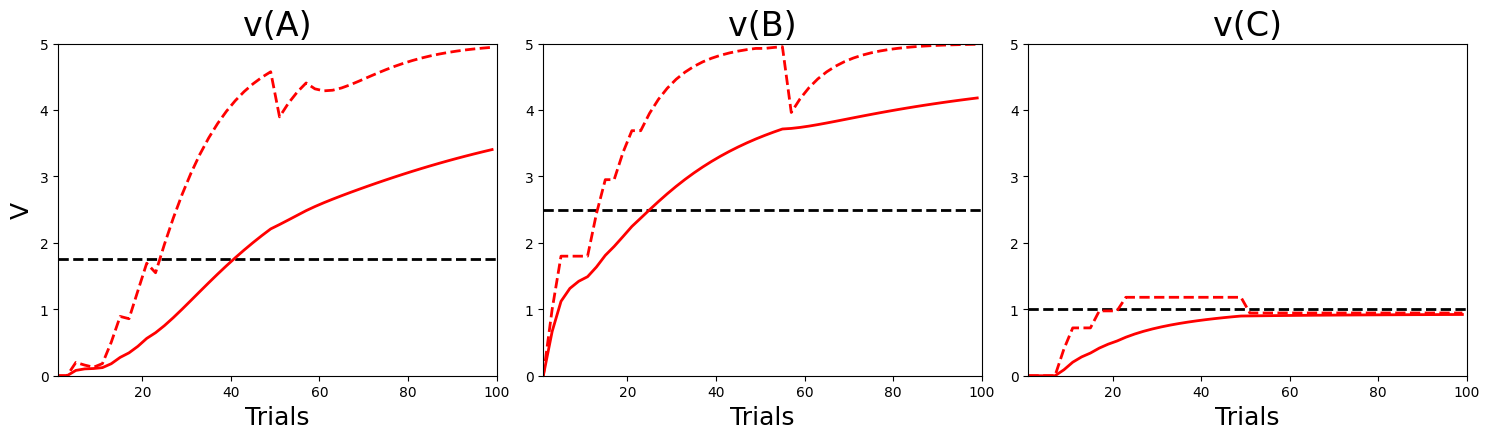

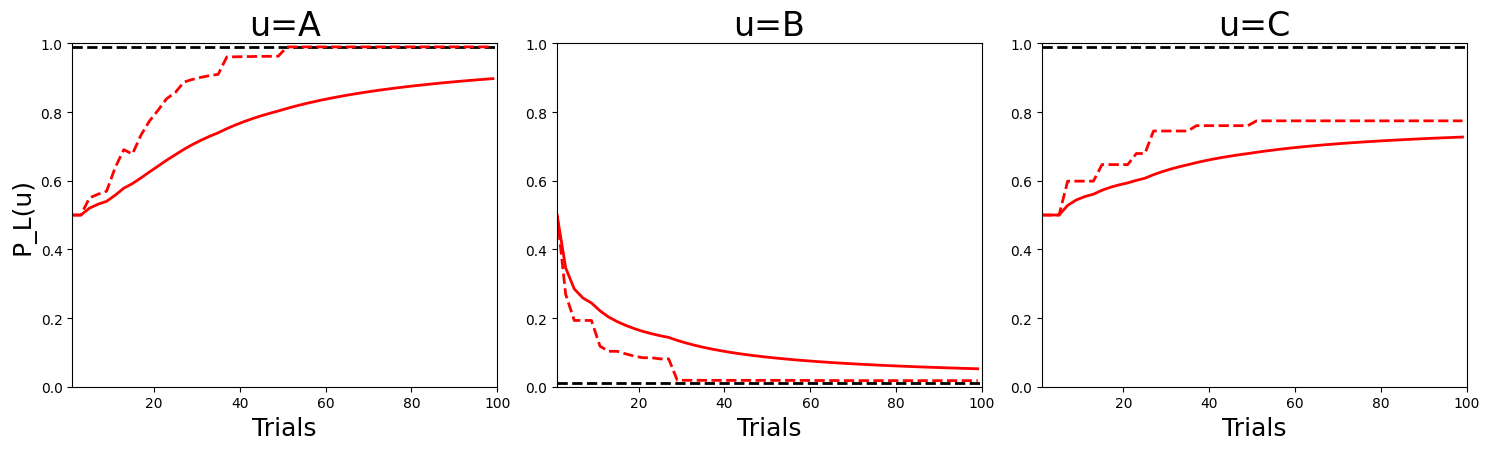

In [ ]:
# @title Alternating trials of policy evaluation and improvement {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt

# Global variables
RW = None  # Immediate rewards
VV = None  # Total future rewards
MM = None  # Action values
PP = None  # Choice probabilities
RR = 2     # Right action
LL = 1     # Left action
AA = 1     # State A
BB = 2     # State B
CC = 3     # State C
epsilon = 0.2  # Learning rate for states
alpha = 0.5    # Learning rate for actions

def increment(xx, tt, iflag):
    """
    Updates state values or policy based on position xx (AA, BB, or CC), action tt (RR or LL),
    and flag (1 for evaluation, 2 for improvement).
    """
    global RW, VV, MM, PP, RR, LL, AA, BB, CC, epsilon, alpha

    if xx == AA and tt == LL:
        delta = RW[LL-1, AA-1] + VV[BB-1] - VV[AA-1]
    elif xx == AA and tt == RR:
        delta = RW[RR-1, AA-1] + VV[CC-1] - VV[AA-1]
    elif xx == BB:
        delta = RW[tt-1, BB-1] - VV[BB-1]
    elif xx == CC:
        delta = RW[tt-1, CC-1] - VV[CC-1]

    if iflag == 1:
        VV[xx-1] = VV[xx-1] + epsilon * delta
    elif iflag == 2:
        MM[tt-1, xx-1] = MM[tt-1, xx-1] + epsilon * (1 - PP[tt-1, xx-1]) * delta
        MM[2-tt, xx-1] = MM[2-tt, xx-1] - epsilon * PP[2-tt, xx-1] * delta

# Parameters
beta = 1       # Exploitation/exploration balance
Ntrial = 100    # Number of trials
nsample = 2    # Samples for plotting

# Initialize arrays
MM = np.zeros((RR, CC))  # Action values
PP = np.zeros((RR, CC))  # Choice probabilities
RW = np.zeros((RR, CC))  # Immediate rewards
RW[RR-1, BB-1] = 5       # Reward for right at B
RW[LL-1, CC-1] = 2       # Reward for left at C
VV = np.zeros(CC)        # Total future rewards
CC_VV = np.zeros((Ntrial, CC))  # Store VV for each trial
CC_PP = np.zeros((Ntrial, CC))  # Store PP for each trial

# Compute initial choice probabilities
PP[LL-1, :] = 1 / (1 + np.exp(beta * (MM[RR-1, :] - MM[LL-1, :])))
PP[RR-1, :] = 1 / (1 + np.exp(beta * (MM[LL-1, :] - MM[RR-1, :])))

# Run the maze, alternating between evaluation and improvement
for i in range(Ntrial):
    # Alternate between policy evaluation and improvement
    flag = 1 if (i % 2) else 2  # flag = 1 for evaluation, 2 for improvement

    # Update choice probabilities
    PP[LL-1, :] = 1 / (1 + np.exp(beta * (MM[RR-1, :] - MM[LL-1, :])))
    PP[RR-1, :] = 1 / (1 + np.exp(beta * (MM[LL-1, :] - MM[RR-1, :])))

    if np.random.rand() < PP[LL-1, AA-1]:  # Left at A to B
        increment(AA, LL, flag)
        if np.random.rand() < PP[LL-1, BB-1]:  # Left at B to T1
            increment(BB, LL, flag)
        else:  # Right at B to T2
            increment(BB, RR, flag)
    else:  # Right at A to C
        increment(AA, RR, flag)
        if np.random.rand() < PP[LL-1, CC-1]:  # Left at C to T3
            increment(CC, LL, flag)
        else:  # Right at C to T4
            increment(CC, RR, flag)

    CC_VV[i, :] = VV
    CC_PP[i, :] = PP[LL-1, :]  # Store left choice probabilities

# Cumulative average for VV
CA_VV = np.cumsum(CC_VV, axis=0)
for i in range(Ntrial):
    CA_VV[i, :] = CA_VV[i, :] / (i + 1)

# Plotting for state values
plt.figure(figsize=(15, 5))
t = np.arange(0, Ntrial, nsample)

# Plot for v(A)
plt.subplot(1, 3, 1)
plt.plot([1, Ntrial], [1.75, 1.75], 'k--', linewidth=2)
plt.plot(t+1, CC_VV[t, AA-1], 'r--', linewidth=2)
plt.plot(t+1, CA_VV[t, AA-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 5])
plt.gca().set_aspect(15, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.ylabel('V', fontsize=18)
plt.title('v(A)', fontsize=24)

# Plot for v(B)
plt.subplot(1, 3, 2)
plt.plot([1, Ntrial], [2.5, 2.5], 'k--', linewidth=2)
plt.plot(t+1, CC_VV[t, BB-1], 'r--', linewidth=2)
plt.plot(t+1, CA_VV[t, BB-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 5])
plt.gca().set_aspect(15, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.title('v(B)', fontsize=24)

# Plot for v(C)
plt.subplot(1, 3, 3)
plt.plot([1, Ntrial], [1, 1], 'k--', linewidth=2)
plt.plot(t+1, CC_VV[t, CC-1], 'r--', linewidth=2)
plt.plot(t+1, CA_VV[t, CC-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 5])
plt.gca().set_aspect(15, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.title('v(C)', fontsize=24)

plt.tight_layout()
plt.show()

# Cumulative average for PP
CA_PP = np.cumsum(CC_PP, axis=0)
for i in range(Ntrial):
    CA_PP[i, :] = CA_PP[i, :] / (i + 1)

# Plotting for choice probabilities
plt.figure(figsize=(15, 5))

# Plot for u=A
plt.subplot(1, 3, 1)
plt.plot([1, Ntrial], [0.99, 0.99], 'k--', linewidth=2)
plt.plot(t+1, CC_PP[t, AA-1], 'r--', linewidth=2)
plt.plot(t+1, CA_PP[t, AA-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 1])
plt.gca().set_aspect(80, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.ylabel('P_L(u)', fontsize=18)
plt.title('u=A', fontsize=24)

# Plot for u=B
plt.subplot(1, 3, 2)
plt.plot([1, Ntrial], [0.01, 0.01], 'k--', linewidth=2)
plt.plot(t+1, CC_PP[t, BB-1], 'r--', linewidth=2)
plt.plot(t+1, CA_PP[t, BB-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 1])
plt.gca().set_aspect(80, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.title('u=B', fontsize=24)

# Plot for u=C
plt.subplot(1, 3, 3)
plt.plot([1, Ntrial], [0.99, 0.99], 'k--', linewidth=2)
plt.plot(t+1, CC_PP[t, CC-1], 'r--', linewidth=2)
plt.plot(t+1, CA_PP[t, CC-1], 'r-', linewidth=2)
plt.axis([1, Ntrial, 0, 1])
plt.gca().set_aspect(80, adjustable='box')
plt.xlabel('Trials', fontsize=18)
plt.title('u=C', fontsize=24)

plt.tight_layout()
plt.show()

# Points to note

<br>

- Using the TD prediction error, we have implemented a *direct actor* with slow and fast *policy improvement*.

<br>

- In the absence of rewards, we adopt a random policy.

<br>

- When rewards are reached and slowly become expected, this expectation gradually becomes associated with earlier and earlier steps.

<br>

- Eventually, rewards are anticipated already at the first step.

<br>

- In general, as policy improves, values functions increase, and *vice versa*.


# 3. AC for larger maze

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_larger.png" width="600">

# Policy evaluation only, first round


Values based on *random policy*.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Large_maze_evaluation_1.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: theoretical prediction for *random policy*.

# Policy improvement only, first round

Based on *values* $v$ from earlier evaluation phase.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Large_maze_improvement_1.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: ideal choice probability.

# Policy evaluation only, second round

With improving policy, values exceed the theoretical predictions for *random policy*.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Large_maze_evaluation_2.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: theoretical predictions for *random policy*.

# Policy improvement only, second round

Retaining values from preceding evaluation phase.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Large_maze_improvement_2.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: ideal choice probability.

# Fast policy iteration (trial-by-trial)

Compare learning rates for values at A, C, D, E!

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Large_maze_iteration_value.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: theoretical predictions for *random policy*.

# Fast policy iteration (trial-by-trial)

Consider evolution of choice A over time!  Why does preferred choice switch from left to right?  Because total expected reward after right turn comes to include large reward at E!

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Large_maze_iteration_policy.png" width="600">

Dashed: trial average. Solid: cumulative average. Dashed black: ideal choice probabilities.


In [ ]:
# @title Alternating trials evaluation and improvement, for larger T-maze {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# Global variables

RR = 2     # Right action
LL = 1     # Left action
AA = 1     # State A
BB = 2     # State B
CC = 3     # State C
DD = 4     # State D
EE = 5     # State E

MM = None  # Action values
PP = None  # Choice probabilities
RW = None  # Immediate rewards
VV = None  # Total future rewards

def increment(xx, tt, epsilon, alpha, iflag):
    """
    Updates state values or policy based on position xx (AA, BB, CC, DD, EE), action tt (RR or LL),
    and flag (1 for evaluation, 2 for improvement).
    """
    global RW, VV, MM, PP, RR, LL, AA, BB, CC, DD, EE

    if xx == AA and tt == LL:
        delta = RW[LL-1, AA-1] + VV[BB-1] - VV[AA-1]
    elif xx == AA and tt == RR:
        delta = RW[RR-1, AA-1] + VV[CC-1] - VV[AA-1]
    elif xx == BB:
        delta = RW[tt-1, BB-1] - VV[BB-1]
    elif xx == CC and tt == LL:
        delta = RW[LL-1, CC-1] - VV[CC-1]
    elif xx == CC and tt == RR:
        delta = RW[RR-1, CC-1] + VV[DD-1] - VV[CC-1]
    elif xx == DD and tt == LL:
        delta = RW[LL-1, DD-1] - VV[DD-1]
    elif xx == DD and tt == RR:
        delta = RW[RR-1, DD-1] + VV[EE-1] - VV[DD-1]
    elif xx == EE:
        delta = RW[tt-1, EE-1] - VV[EE-1]

    if iflag == 1:
        VV[xx-1] = VV[xx-1] + epsilon * delta
    if iflag == 2:
        MM[tt-1, xx-1] = MM[tt-1, xx-1] + alpha * (1 - PP[tt-1, xx-1]) * delta
        MM[2-tt, xx-1] = MM[2-tt, xx-1] - alpha * PP[2-tt, xx-1] * delta

def runmaze(Ntrial, beta, epsilon, alpha, iflag):
    """
    Runs the maze for Ntrial trials with the specified flag (3 for alternating evaluation and improvement).
    Returns CC_VV (state values) and CC_PP (choice probabilities).
    """
    global RW, VV, MM, PP, RR, LL, AA, BB, CC, DD, EE

    CC_VV = np.zeros((Ntrial, EE))
    CC_PP = np.zeros((Ntrial, EE))

    for i in range(Ntrial):
        if iflag == 3:
            flag = 1 if (i % 2) else 2  # Alternate: 1 for evaluation, 2 for improvement

        # Compute policy from action values
        PP[LL-1, :] = 1 / (1 + np.exp(beta * (MM[RR-1, :] - MM[LL-1, :])))
        PP[RR-1, :] = 1 / (1 + np.exp(beta * (MM[LL-1, :] - MM[RR-1, :])))

        if np.random.rand() < PP[LL-1, AA-1]:  # Left at A to B
            increment(AA, LL, epsilon, alpha, flag)
            if np.random.rand() < PP[LL-1, BB-1]:  # Left at B to T1
                increment(BB, LL, epsilon, alpha, flag)
            else:  # Right at B to T2 (small reward)
                increment(BB, RR, epsilon, alpha, flag)
        else:  # Right at A to C
            increment(AA, RR, epsilon, alpha, flag)
            if np.random.rand() < PP[LL-1, CC-1]:  # Left at C to T3
                increment(CC, LL, epsilon, alpha, flag)
            else:  # Right at C to D
                increment(CC, RR, epsilon, alpha, flag)
                if np.random.rand() < PP[LL-1, DD-1]:  # Left at D to T4
                    increment(DD, LL, epsilon, alpha, flag)
                else:  # Right at D to E
                    increment(DD, RR, epsilon, alpha, flag)
                    if np.random.rand() < PP[LL-1, EE-1]:  # Left at E to T5 (big reward)
                        increment(EE, LL, epsilon, alpha, flag)
                    else:  # Right at E to T6
                        increment(EE, RR, epsilon, alpha, flag)

        CC_VV[i, :] = VV
        CC_PP[i, :] = PP[LL-1, :]

    return CC_VV, CC_PP

def plotvalues(Ntrial, CC_VV, nsample):
    """
    Plots the state values for each state (A, B, C, D, E) over trials.
    """
    global RW, VV, MM, PP, RR, LL, AA, BB, CC, DD, EE

    # Cumulative average
    CA_VV = np.cumsum(CC_VV, axis=0)
    for i in range(Ntrial):
        CA_VV[i, :] = CA_VV[i, :] / (i + 1)

    # Values assuming random policy
    VEE = (5 + 0) / 2
    VDD = (VEE + 0) / 2
    VCC = (VDD + 0) / 2
    VBB = (1 + 0) / 2
    VAA = (VBB + VCC) / 2

    # aspect ratio

    ar = 35

    plt.figure(figsize=(15, 10))
    t = np.arange(0, Ntrial, nsample)

    # Plot for v(A)
    plt.subplot(2, 3, 1)
    plt.plot([1, Ntrial], [VAA, VAA], 'k--', linewidth=2)
    plt.plot(t+1, CC_VV[t, AA-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_VV[t, AA-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 5])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.ylabel('V', fontsize=18)
    plt.title('v(A)', fontsize=24)

    # Plot for v(B)
    plt.subplot(2, 3, 2)
    plt.plot([1, Ntrial], [VBB, VBB], 'k--', linewidth=2)
    plt.plot(t+1, CC_VV[t, BB-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_VV[t, BB-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 5])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.title('v(B)', fontsize=24)

    # Plot for v(C)
    plt.subplot(2, 3, 3)
    plt.plot([1, Ntrial], [VCC, VCC], 'k--', linewidth=2)
    plt.plot(t+1, CC_VV[t, CC-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_VV[t, CC-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 5])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.title('v(C)', fontsize=24)

    # Plot for v(D)
    plt.subplot(2, 3, 4)
    plt.plot([1, Ntrial], [VDD, VDD], 'k--', linewidth=2)
    plt.plot(t+1, CC_VV[t, DD-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_VV[t, DD-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 5])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.title('v(D)', fontsize=24)

    # Plot for v(E)
    plt.subplot(2, 3, 5)
    plt.plot([1, Ntrial], [VEE, VEE], 'k--', linewidth=2)
    plt.plot(t+1, CC_VV[t, EE-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_VV[t, EE-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 5])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.title('v(E)', fontsize=24)

    plt.tight_layout()
    plt.show()

def plotpolicy(Ntrial, CC_PP, nsample):
    """
    Plots the choice probabilities for each state (A, B, C, D, E) over trials.
    """
    global RW, VV, MM, PP, RR, LL, AA, BB, CC, DD, EE

    # Cumulative average
    CA_PP = np.cumsum(CC_PP, axis=0)
    for i in range(Ntrial):
        CA_PP[i, :] = CA_PP[i, :] / (i + 1)

    # Ideal choice probabilities
    PAA = 0.01  # Right
    PBB = 0.01  # Right
    PCC = 0.01  # Right
    PDD = 0.01  # Right
    PEE = 0.99  # Left

    # aspect ratio

    ar = 150

    plt.figure(figsize=(15, 10))
    t = np.arange(0, Ntrial, nsample)

    # Plot for u=A
    plt.subplot(2, 3, 1)
    plt.plot([1, Ntrial], [PAA, PAA], 'k--', linewidth=2)
    plt.plot(t+1, CC_PP[t, AA-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_PP[t, AA-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 1])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.ylabel('P_L(u)', fontsize=18)
    plt.title('u=A', fontsize=24)

    # Plot for u=B
    plt.subplot(2, 3, 2)
    plt.plot([1, Ntrial], [PBB, PBB], 'k--', linewidth=2)
    plt.plot(t+1, CC_PP[t, BB-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_PP[t, BB-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 1])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.title('u=B', fontsize=24)

    # Plot for u=C
    plt.subplot(2, 3, 3)
    plt.plot([1, Ntrial], [PCC, PCC], 'k--', linewidth=2)
    plt.plot(t+1, CC_PP[t, CC-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_PP[t, CC-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 1])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.title('u=C', fontsize=24)

    # Plot for u=D
    plt.subplot(2, 3, 4)
    plt.plot([1, Ntrial], [PDD, PDD], 'k--', linewidth=2)
    plt.plot(t+1, CC_PP[t, DD-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_PP[t, DD-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 1])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.title('u=D', fontsize=24)

    # Plot for u=E
    plt.subplot(2, 3, 5)
    plt.plot([1, Ntrial], [PEE, PEE], 'k--', linewidth=2)
    plt.plot(t+1, CC_PP[t, EE-1], 'r:', linewidth=2)
    plt.plot(t+1, CA_PP[t, EE-1], 'r-', linewidth=2)
    plt.axis([1, Ntrial, 0, 1])
    plt.gca().set_aspect( ar, adjustable='box')
    plt.xlabel('Trials', fontsize=18)
    plt.title('u=E', fontsize=24)

    plt.tight_layout()
    plt.show()


def plot_large_maze_behavior( beta = 1, epsilon = 0.4, alpha = 0.2 ):

    global RW, VV, MM, PP, RR, LL, AA, BB, CC, DD, EE

    # beta = 1   # Exploitation/exploration balance
    # epsilon = 0.5  # Learning rate for values
    # alpha = 0.4    # Learning rate for actions

    # Parameters
    Ntrial = 200   # Number of trials
    nsample = 10   # Samples for plotting

    # Initialize arrays
    MM = np.zeros((RR, EE))  # Action values
    PP = np.zeros((RR, EE))  # Choice probabilities
    RW = np.zeros((RR, EE))  # Immediate rewards
    RW[RR-1, BB-1] = 1       # Reward for right at B
    RW[LL-1, EE-1] = 5       # Reward for left at E
    VV = np.zeros(EE)        # Total future rewards

    # Compute initial choice probabilities
    PP[LL-1, :] = 1 / (1 + np.exp(beta * (MM[RR-1, :] - MM[LL-1, :])))
    PP[RR-1, :] = 1 / (1 + np.exp(beta * (MM[LL-1, :] - MM[RR-1, :])))

    # Run the maze
    flag = 3  # Alternate values and policy
    CC_VV, CC_PP = runmaze(Ntrial, beta, epsilon, alpha, flag)

    # Plot results
    plotvalues(Ntrial, CC_VV, nsample)
    plotpolicy(Ntrial, CC_PP, nsample)

interact( plot_large_maze_behavior, beta =(1,20,1), alpha=(0.1,0.5,0.1), epsilon=(0.1,0.5,0.1) )


interactive(children=(IntSlider(value=1, description='beta', max=20, min=1), FloatSlider(value=0.4, descriptio…

<function __main__.plot_large_maze_behavior(beta=1, epsilon=0.4, alpha=0.2)>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Maze_larger.png" width="600">

# Points to note

<br>

- Using the TD prediction error, we have implemented a *direct actor* with slow and fast *policy improvement*.

<br>

- Reward expectations are gradually passed form later states back to earlier states.

<br>

- As more information about delayed rewards becomes available, earlier choices may change.

<br>

- The optimal policy/value combination is reached after a (large) number of trials.


# **4. Morris water maze**

Rats are placed repeatedly in milky water and swim to find a small submerged platform.  Eventually, the animals learn to swim directly to the platform.

<br>

We want to analyze this behaviour in terms of an actor-critic model.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_water_maze.jpg" width="600">

# Experimental results

<br>

*Place*: 20 trials with platform at same location, further 4 trials at different locations.

<br>

*Random*: Platform position varied from trial to trial.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig3.jpg" width="600">

# Critic

We postulate 'place cell' activities $f_i(p)$to represent position within the maze and a 'critic' activity $C(p)$ that evaluates position (from accumulated experience $w_i$).

Total expected reward is represented by the firing of a single cell $C$, which reflects the weighted sum of place cell inputs $f_i(p)$:


$$
C(p) = \sum_i \, w_i \, f_i(p)
$$

The weights $w_i$ of active place cells are adjusted with

$$
w_i \to w_i + \epsilon \, \delta_t \, f_i(p)
$$

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig1.jpg" width="600">

# Actor

<br>

We further postulate 'action cell' activities $a_j(p)$ that represent action values and action probabilities.

<br>

At each location $p$, eight 'action cells' $a_j(p)$ represent different swim directions.  Their activity is a weighted sum of place cell activity:

$$
a_j(p) = \sum_i \, z_{ji} \, f_i(p), \qquad\qquad P_j = \frac{\exp(2\, a_j)}{\sum_k \, \exp(2\, a_k)}
$$

Together, 'action cell' activities determines the probability of swimming in a particular direction:

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig1.jpg" width="600">

# Experience-driven development of weights

<br>

Place values (top) and action values (bottom)

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig2.jpg" width="600">

# Animal performance

<br>

Let's compare animal and model performance.  Here are some further observations of animal performance:

<br>

Same position (1-7 and 8-9) $\qquad\qquad\qquad$ New position each day

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig0.jpg" width="600">

# Model performance

<br>

Subjected to comparable experience, the behaviour of the model is rather different.

<br>

Same position (1-7 and 8-9) $\qquad\qquad\qquad$ New position each day

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig4.jpg" width="600">

Model must unlearn old position before learning new position!

# Points to note

<br>

- Our MWM model includes *place cells* $i$, an *expected value cell* (critic), and several *action cells* $j$.

<br>

- Learning increments feedforward weights $w_i$ (place $\to$ value) and $z_{ij}$ (place $\to$ action).

<br>

- Initially, the value function peaks at the platform location.  Subsequently, it spreads over the entire pool.

<br>

- Action values gradually favor the swim direction pointing towards the platform.

<br>

- Value function and action values are incremented with the TD prediction error.

<br>

- Incremental learning of expected value is obtained.

# Comparison of animal and model


<br>

- Unlike animal, model does not need to be refreshed.

<br>

- Unlike animal, model fails to generalize, even partially, to new platform positions.

<br>

- Unlike animal, model learning starts from neutral or even unfavourable initial conditions.

# **5. Extended actor-critic model**

<br>

Let's extend our model and introduce a general sense of direction. This will allow the model to become increasingly familiar with the maze and an ability and to generalize from one platform position to another.

<br>

We forego implementing a daily 'reset' or 'refresh'.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig6.jpg" width="600">

Extended model includes information that generalizes to new platform positions:

<br>

- X-Y cells learn to represent position within pool (from place cell input).

<br>

- X'-Y' cells represent current platform location (`wherever I am, this is the direction to take').

<br>

- 'Global' swim direction is computed from comparison.

<br>

Other aspect remained unchanged:

- `Local' swim direction still learned from prediction error.

- Value function still learned from prediction error.

- Prediction error still computed from reward (reaching platform) and from change in value function.

# X-Y coordinate cells

Model results:

**a)** activity of X-Y coordinate cells with increasing experience.

**b)** swim direction with increasing experience




<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig6.jpg" width="600">

# Gradient of coordinate functions

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig7.jpg" width="600">


<br>

# Performance of extended model

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Morris_Fig8.jpg" width="600">

# Comparing animal and model performance

<br>

- Model does not need to be refreshed.

- Model now generalizes, at least partially, to new platform positions.

- Global swim direction (coordinate cells) does not need to be relearned.

- Learning of local swim direction starts over from zero.


# **Reinforcement summary I**


<br>

- Reinforcement learning explains  *classical* and *instrumental conditioning*.

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Summary_RL.jpg" width="400">


- *Rescorla-Wagner* rule evaluates environment in terms of expected immediate reward:  *Pavlovian -- Extinction -- Partial -- Blocking -- Inhibitory -- Overshadowing*


- *Temporal-difference* rule in terms of total expected total (immediate and delayed): *Trace -- Secondary*

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Summary_episodic.png" width="300">
<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Summary_TC.jpg" width="300">

# **Reinforcement summary II**

<br>

- *TD prediction error* shifts from reward to earlier, predictive events.

- *TD prediction error* combines actual reward with 'change in hopes' (total expected reward):

$$
\delta(s,a) = r(s,a) - v(s) + v(s') \qquad\qquad s \rarrow^a s'
$$

- *TD prediction error* 'bootstraps' newer estimates from older estimates (and occasional reward).

- *TD prediction error* can serve to increment both values and policies.

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Summary_AC.png" width="300">

# **Reinforcement summary III**

In static action choice, learning of *action policy* maximizes expected immediate reward.

<br>

- *Direct actor* maximizes total expected reward.

- *Indirect actor* learns expected rewards for individual actions.

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Summary_direct_indirect.jpg" width="300">

<br>

In sequential action choice, learning maximizes expected total reward (immediate and delayed).

- *Policy evaluation* assesses the value (total expected reward) of states, given a fixed policy.

- *Policy improvement* assesses the policy, given a fixed value.

- *Policy iteration* alternates between evaluation and improvement.


# **Reinforcement summary IV**

<br>

- In *actor-critic models*, evaluation is performed by the *critic* (value function) and improvement by the *actor* (policy).

- Actor and critic may be incremented either in alternation or concurrently, using the TD prediction error.

- Actor-critic models develop foresight when sequential actions lead to delayed rewards.

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Summary_GW.png" width="200">

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec12_Summary_maze.png" width="200">


# **Next:**


# $\qquad\qquad$**Representational learning**